In [1]:
print()
import cv2
import numpy as np
from tensorflow.keras.applications.densenet import preprocess_input
from utils import preprocess_image

In [2]:
NORMAL_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/Normal/Normal-20.png'
COVID_ERROR_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/COVID/COVID-56.png'
COVID_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/COVID/COVID-114.png'
VIRAL_PNEUMONIA_IMG_PATH='C:/Users/PratushPc/OneDrive/Desktop/ExCV/data/COVID_19_dataset/test/Viral Pneumonia/Viral Pneumonia-41.png'

In [3]:
from tensorflow.keras.models import load_model
model=load_model('C:\\Users\\PratushPc\\OneDrive\\Desktop\\ExCV\\models\\best_model.keras')

In [4]:
from tf_explain.core.integrated_gradients import IntegratedGradients

img,processed_img=preprocess_image(COVID_IMG_PATH)
pred=model.predict(processed_img,verbose=0)
pred_class=np.argmax(pred[0])


In [5]:
explainer=IntegratedGradients()

grid=explainer.explain(
    (processed_img,
    None),
    model,
    class_index=pred_class
)

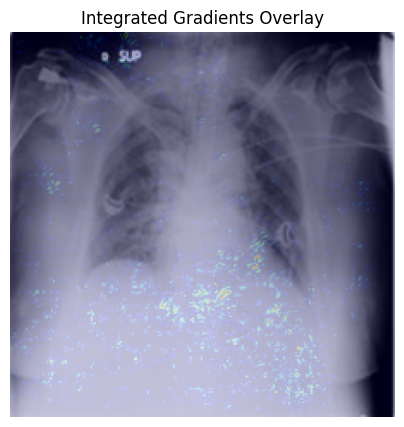

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(img[0])

plt.imshow(
    grid,
    cmap='jet',
    alpha=0.2
)

plt.axis("off")
plt.title("Integrated Gradients Overlay")

plt.show()